In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/processed (1).zip"
extract_path = "/content/yelp_data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped to:", extract_path)

Unzipped to: /content/yelp_data


In [7]:
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

In [8]:
class YelpFolderDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_paths = []
        self.transform = transform
        for label_folder in os.listdir(root_dir):
            folder_path = os.path.join(root_dir, label_folder)
            if os.path.isdir(folder_path):
                self.image_paths += [
                    os.path.join(folder_path, f)
                    for f in os.listdir(folder_path)
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
                ]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        return self.transform(img) if self.transform else img


In [9]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

In [10]:
train_folder = "/content/yelp_data/processed/train"
dataset = YelpFolderDataset(train_folder, transform)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

print(f"Loaded {len(dataset)} images from {train_folder}")

Loaded 160602 images from /content/yelp_data/processed/train


In [11]:
pip install diffusers accelerate transformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 99.1 MB/s eta 0:00:00


In [12]:
from diffusers import DDPMPipeline
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

pipeline = DDPMPipeline.from_pretrained("google/ddpm-cifar10-32").to(device)

print("DDPM model loaded on", device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/699 [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

diffusion_pytorch_model.bin:   0%|          | 0.00/143M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


DDPM model loaded on cpu


In [13]:
import matplotlib.pyplot as plt

os.makedirs("ddpm_generated", exist_ok=True)
generated_images = []

for i in range(5):
    image = pipeline().images[0]
    path = f"ddpm_generated/ddpm_image_{i+1}.png"
    image.save(path)
    generated_images.append(path)

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

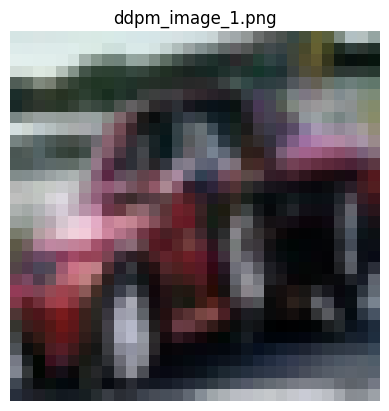

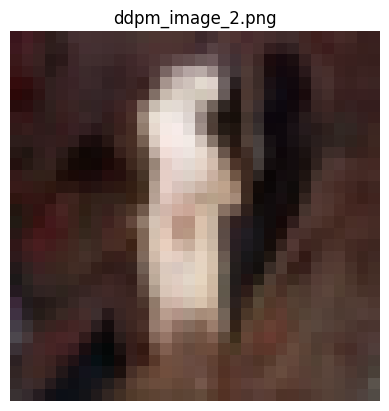

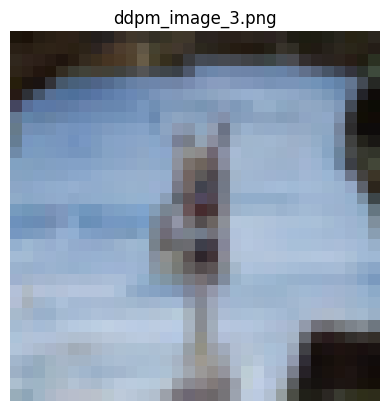

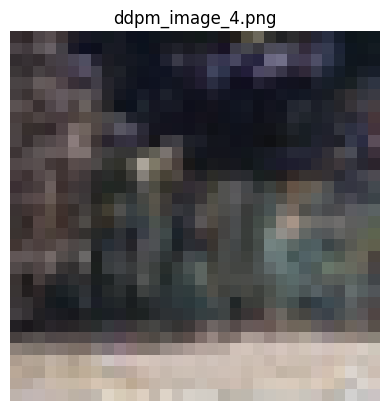

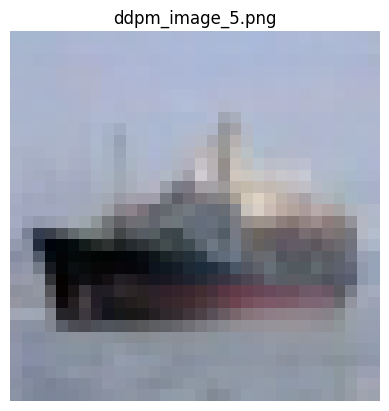

In [14]:
for img_path in generated_images:
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis("off")
    plt.title(os.path.basename(img_path))
    plt.show()

In [15]:
torch.save(pipeline.unet.state_dict(), "ddpm_generated/ddpm_unet_checkpoint.pth")

In [16]:
with open("ddpm_generated/ddpm_log.txt", "w") as f:
    f.write("Devanshi – DDPM \n")
    f.write("Model: google/ddpm-cifar10-32\n")
    f.write(f"Dataset: {train_folder} (5 class folders)\n")
    f.write("Generated 5 images\n")
    f.write("Saved UNet checkpoint\n")

print("Checkpoint and log saved.")

Checkpoint and log saved.


In [17]:
import os
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from diffusers import UNet2DModel, DDPMScheduler, DDPMPipeline
from diffusers.optimization import get_scheduler
from PIL import Image
from tqdm import tqdm


In [21]:
class YelpDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_paths = []
        self.transform = transform
        for folder in os.listdir(root_dir):
            folder_path = os.path.join(root_dir, folder)
            if os.path.isdir(folder_path):
                self.image_paths += [
                    os.path.join(folder_path, f)
                    for f in os.listdir(folder_path)
                    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
                ]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    lambda x: (x - 0.5) * 2  # scale to [-1, 1]
])

dataset = YelpDataset("/content/yelp_data/processed/train", transform)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)


JEFFIN JOHN ABRAHAM

In [22]:
from diffusers import UNet2DModel

model = UNet2DModel(
    sample_size=32,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 128),
    down_block_types=("DownBlock2D", "DownBlock2D", "DownBlock2D"),
    up_block_types=("UpBlock2D", "UpBlock2D", "UpBlock2D")
).to(device)


In [28]:
from diffusers import DDPMScheduler
import torch.nn as nn
import torch
from tqdm import tqdm


device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)


scheduler = DDPMScheduler(num_train_timesteps=500)


optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


small_dataset = torch.utils.data.Subset(dataset, range(0, 500))  # Use first 500 images
dataloader = DataLoader(small_dataset, batch_size=16, shuffle=True)

# ✅ Quick training loop (only 1 epoch and 20 batches max)
epochs = 1
model.train()
for epoch in range(epochs):
    for step, batch in enumerate(tqdm(dataloader, desc=f"Epoch {epoch+1}")):
        if step > 20:  # Limit to 20 batches for faster execution
            break

        batch = batch.to(device)
        noise = torch.randn_like(batch).to(device)
        timesteps = torch.randint(0, scheduler.config.num_train_timesteps, (batch.shape[0],), device=device).long()

        noisy = scheduler.add_noise(batch, noise, timesteps)
        pred = model(noisy, timesteps).sample

        loss = nn.MSELoss()(pred, noise)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    print(f" Epoch {epoch+1} completed. Final loss: {loss.item():.4f}")


Epoch 1:  66%|██████▌   | 21/32 [01:10<00:36,  3.35s/it]

 Epoch 1 completed. Final loss: 0.2248


In [29]:
from diffusers import DDPMPipeline

pipeline = DDPMPipeline(unet=model, scheduler=scheduler).to(device)
images = pipeline(num_inference_steps=50).images

os.makedirs("ddpm_generated", exist_ok=True)
for i, img in enumerate(images):
    img.save(f"ddpm_generated/ddpm_image_yelp_{i+1}.png")


  0%|          | 0/50 [00:00<?, ?it/s]

In [30]:
from diffusers import UNet2DModel, DDPMScheduler
import torch.nn as nn
import torch
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"

# Define DDPM model
model = UNet2DModel(
    sample_size=32,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 128),
    down_block_types=("DownBlock2D", "DownBlock2D", "DownBlock2D"),
    up_block_types=("UpBlock2D", "UpBlock2D", "UpBlock2D")
).to(device)

# Custom hyperparameters
scheduler = DDPMScheduler(
    num_train_timesteps=1000,         # Can change to 500/750 later
    beta_schedule="squaredcos_cap_v2" # Try 'linear' vs 'cosine' vs 'squaredcos_cap_v2'
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Training loop
model.train()
epochs = 1
for epoch in range(epochs):
    for batch in tqdm(dataloader):
        batch = batch.to(device)
        noise = torch.randn_like(batch).to(device)
        timesteps = torch.randint(0, 1000, (batch.shape[0],), device=device).long()
        noisy = scheduler.add_noise(batch, noise, timesteps)
        pred = model(noisy, timesteps).sample
        loss = nn.MSELoss()(pred, noise)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    print(f"Epoch {epoch+1} done")


100%|██████████| 32/32 [01:44<00:00,  3.28s/it]

Epoch 1 done


In [31]:
from diffusers import DDPMPipeline
import os
from PIL import Image

pipeline = DDPMPipeline(unet=model, scheduler=scheduler).to(device)

# Generate 5 images
images = pipeline(num_inference_steps=50, generator=torch.manual_seed(42)).images

# Save them
os.makedirs("ddpm_generated", exist_ok=True)
for i, img in enumerate(images):
    img.save(f"ddpm_generated/ddpm_image_{i+1}.png")
print(" 5 Yelp-based DDPM images saved.")


  0%|          | 0/50 [00:00<?, ?it/s]

 5 Yelp-based DDPM images saved.


In [32]:
torch.save(model.state_dict(), "ddpm_generated/ddpm_yelp_unet.pth")

with open("ddpm_generated/ddpm_log.txt", "w") as f:
    f.write("Jeffin – DDPM\n")
    f.write("Fine-tuned DDPM with: cosine schedule, 1000 steps, 1 epoch\n")
    f.write("Generated 5 Yelp images\n")
    f.write("Saved UNet checkpoint\n")
